# Social Media Performance

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading & Preparation

In [2]:
df = pd.read_csv('social_media_performance.csv')
df

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
0,1,LinkedIn,article,Technology,UR,BR,2025-04-25 09:47:00,#AI #Innovation #TechTrends #Programming #Codi...,0.76,37781,1202,462,185,0.0490,0
1,2,LinkedIn,poll,Health,FR,JP,2025-10-29 09:44:00,#Fitness #Nutrition #Wellness #Health #MentalH...,0.46,23541,1399,538,215,0.0915,1
2,3,LinkedIn,article,Travel,HI,FR,2025-02-10 14:12:00,#Travel #Journey #Adventure #Tourism #ExploreM...,-0.01,30714,1663,639,255,0.0833,1
3,4,LinkedIn,image,Sports,DE,DE,2025-04-18 22:41:00,#Cricket #Workout #Fitness,0.55,31294,1372,528,211,0.0675,0
4,5,LinkedIn,poll,Business,DE,US,2025-04-28 10:17:00,#Entrepreneur #Leadership #StartupLife,0.70,43129,2234,859,343,0.0797,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,YouTube,video,Food,PT,IN,2025-02-22 19:01:00,#Foodie #Cooking #Food #Recipe #FoodBlog #MustTry,-0.05,430376,39279,15107,6043,0.1404,1
9996,9997,YouTube,video,Technology,DE,US,2025-01-18 20:51:00,#Programming #DataScience #CodingLife #Innovat...,0.61,559223,12513,4812,1925,0.0344,0
9997,9998,YouTube,video,Entertainment,JA,IN,2025-08-12 20:58:00,#Funny #Viral #ShowBiz,0.78,833212,31796,12229,4891,0.0587,0
9998,9999,YouTube,video,Health,EN,DE,2025-04-27 19:04:00,#Wellness #Health #MentalHealth #Fitness #Nutr...,0.49,182707,15690,6034,2413,0.1321,1


Check for missing vals.

In [3]:
df.isnull().sum()

,0
post_id,0
platform,0
content_type,0
topic,0
language,0
region,0
post_datetime,0
hashtags,0
sentiment_score,0
views,0


Check datatype of the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          10000 non-null  int64  
 1   platform         10000 non-null  object 
 2   content_type     10000 non-null  object 
 3   topic            10000 non-null  object 
 4   language         10000 non-null  object 
 5   region           10000 non-null  object 
 6   post_datetime    10000 non-null  object 
 7   hashtags         10000 non-null  object 
 8   sentiment_score  10000 non-null  float64
 9   views            10000 non-null  int64  
 10  likes            10000 non-null  int64  
 11  comments         10000 non-null  int64  
 12  shares           10000 non-null  int64  
 13  engagement_rate  10000 non-null  float64
 14  is_viral         10000 non-null  int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 1.1+ MB


### 2. Exploratory Data Analysis (EDA)

Convert 'post_datetime' to datetime objects to enable time-based analysis for temporal patterns.


In [5]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   post_id          10000 non-null  int64         
 1   platform         10000 non-null  object        
 2   content_type     10000 non-null  object        
 3   topic            10000 non-null  object        
 4   language         10000 non-null  object        
 5   region           10000 non-null  object        
 6   post_datetime    10000 non-null  datetime64[ns]
 7   hashtags         10000 non-null  object        
 8   sentiment_score  10000 non-null  float64       
 9   views            10000 non-null  int64         
 10  likes            10000 non-null  int64         
 11  comments         10000 non-null  int64         
 12  shares           10000 non-null  int64         
 13  engagement_rate  10000 non-null  float64       
 14  is_viral         10000 non-null  int64 

Calculate & visualize the average performance metrics (engagement_rate, views, likes, comments, shares) for each combination of 'platform' & 'content_type'. This will help identify which content types perform best on specific platforms.

To do so, group the DataFrame by these two columns and then calculate the mean for the specified performance metrics.

In [6]:
performance_metrics = ['engagement_rate', 'views', 'likes', 'comments', 'shares']
platform_content_type_performance = df.groupby(['platform', 'content_type'])[performance_metrics].mean().reset_index()
print("Average performance metrics by platform and content type:\n")
print(platform_content_type_performance.head())

Average performance metrics by platform and content type:

    platform content_type  engagement_rate          views         likes  \
0  Instagram     carousel         0.154878  251224.702760  24761.847134   
1  Instagram         feed         0.152081  266166.527273  26579.068687   
2  Instagram        image         0.151512  257045.998004  25431.027944   
3  Instagram         reel         0.145252  262367.846457  24822.399606   
4  Instagram        story         0.148489  247299.066667  24057.779048   

       comments       shares  
0   9523.609342  3809.154989  
1  10222.523232  4088.715152  
2   9780.974052  3912.075848  
3   9546.852362  3818.454724  
4   9252.779048  3700.817143  


Visualize the average performance metrics across different platforms and content types by creating bar plots for each metric. This allows for a clear comparison of how different content types perform on various platforms based on engagement, views, likes, comments, and shares.



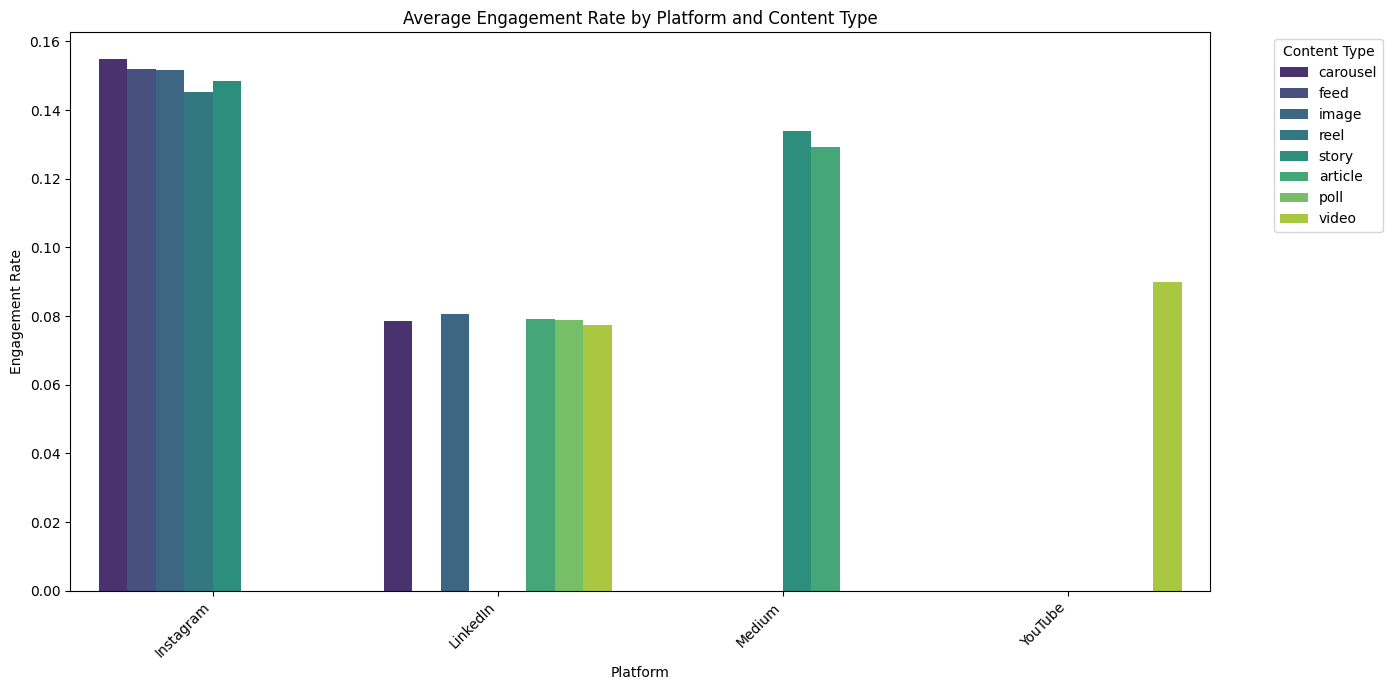

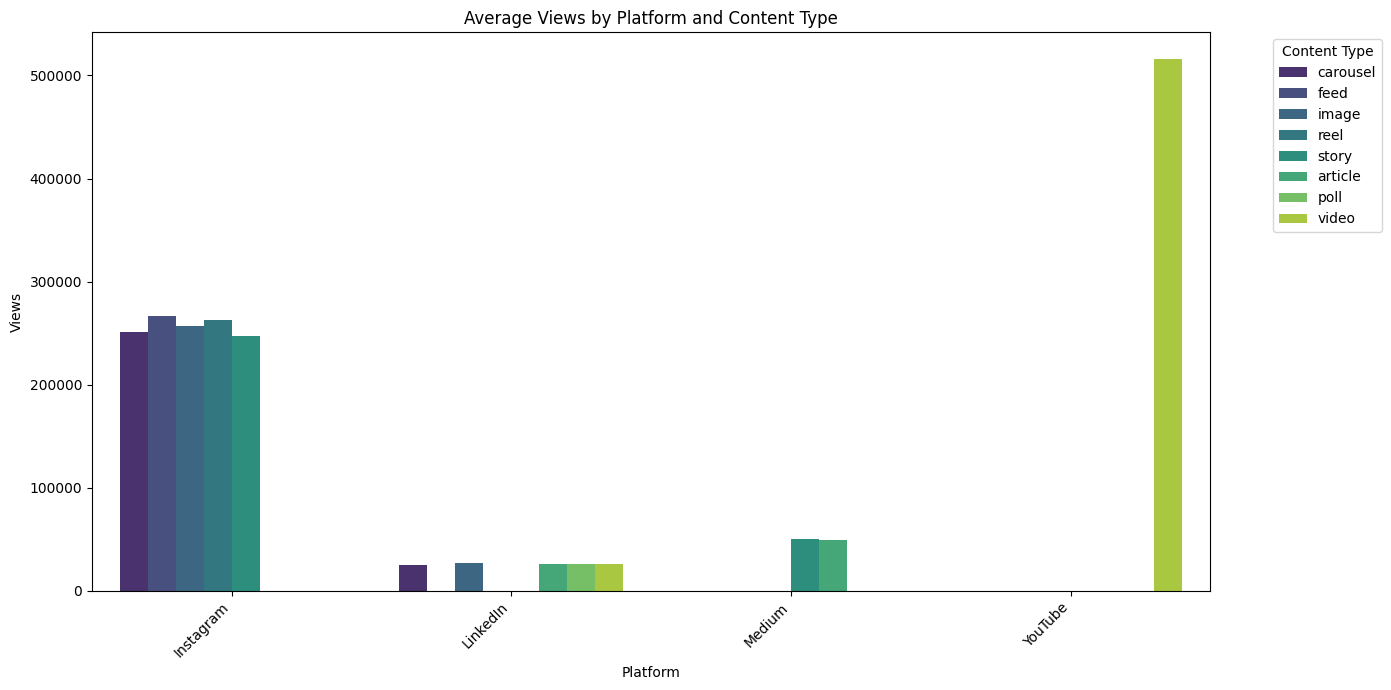

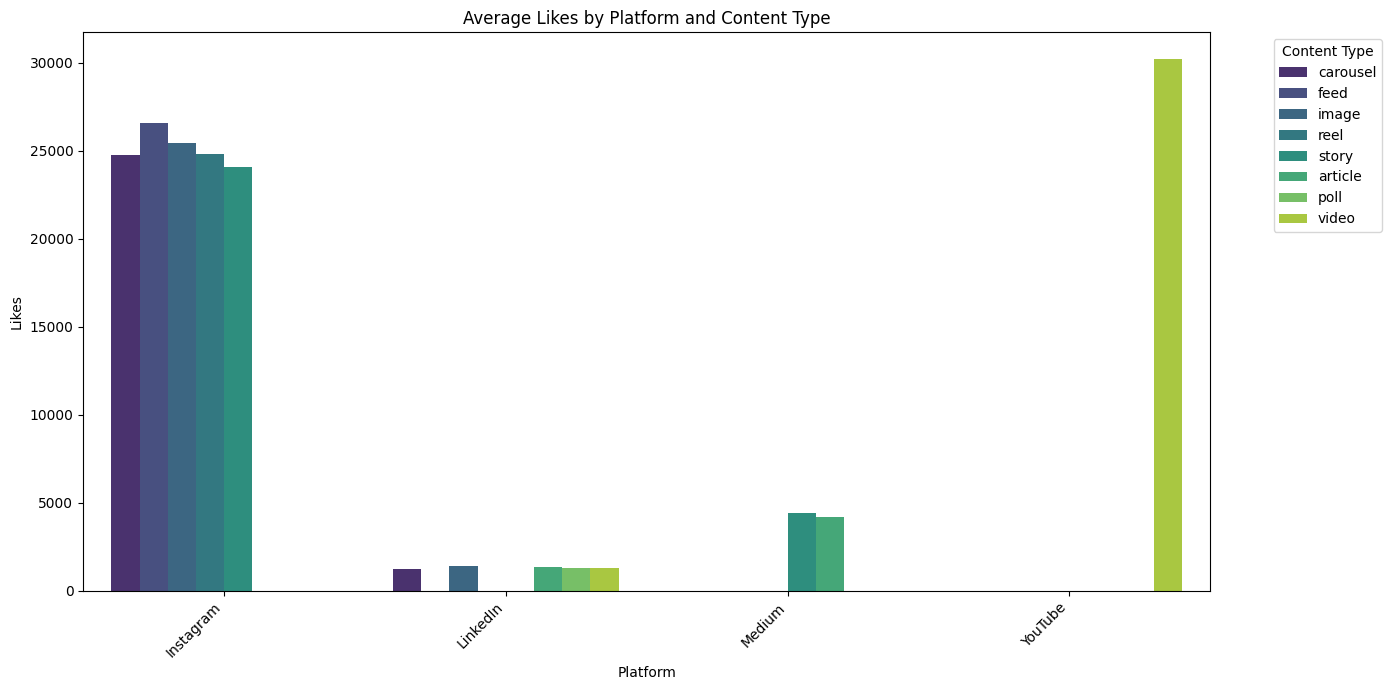

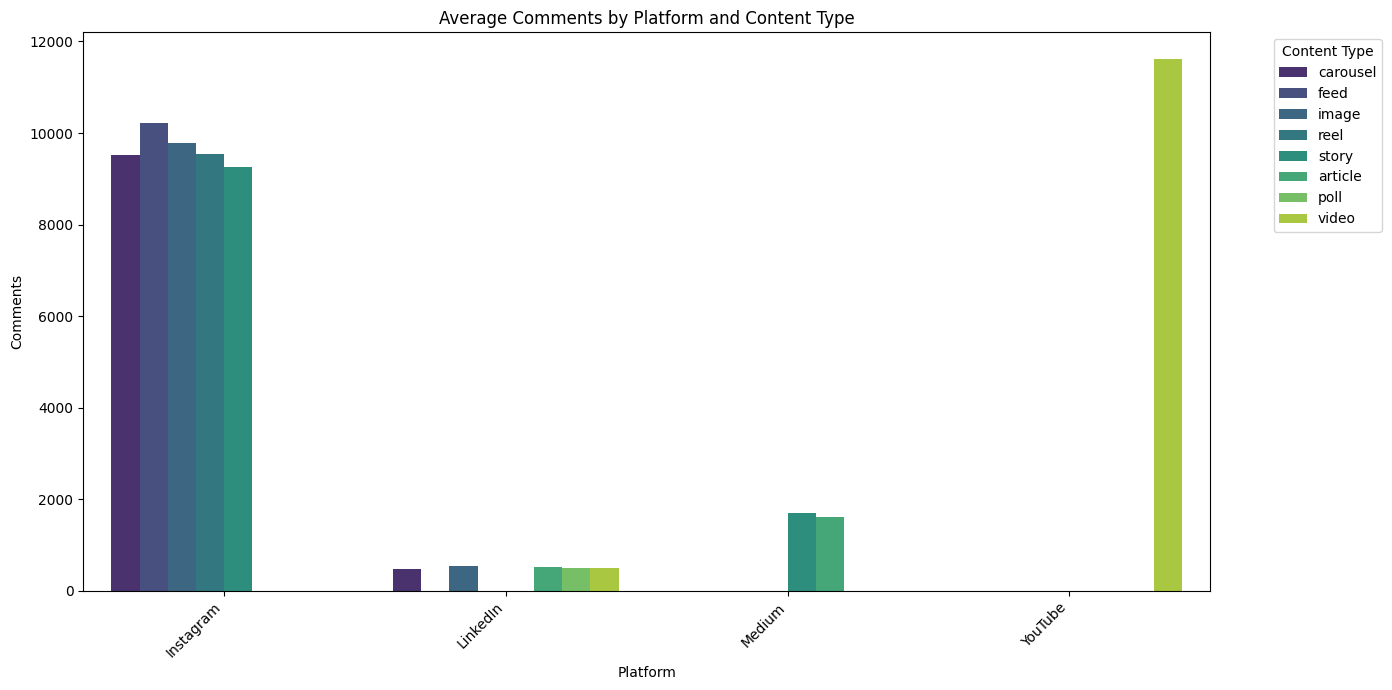

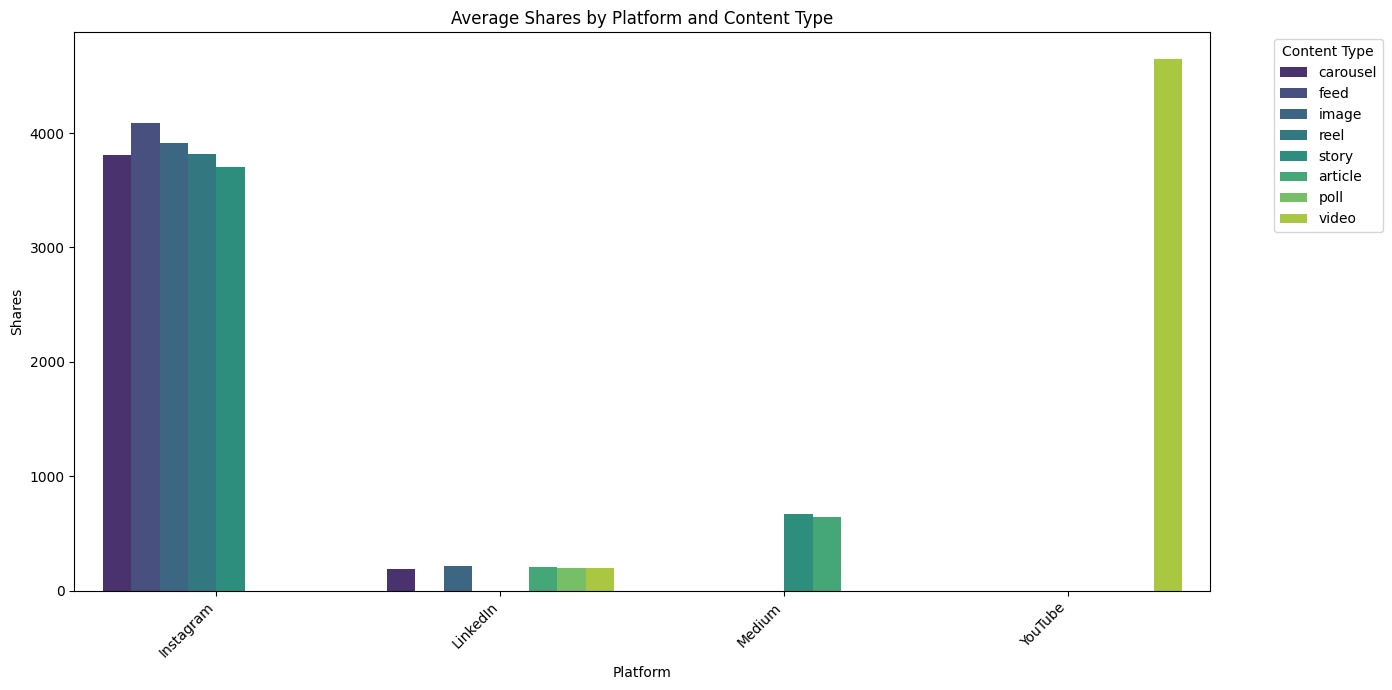

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for metric in performance_metrics:
    plt.figure(figsize=(14, 7))
    sns.barplot(data=platform_content_type_performance, x='platform', y=metric, hue='content_type', palette='viridis')
    plt.title(f'Average {metric.replace("_", " ").title()} by Platform and Content Type')
    plt.xlabel('Platform')
    plt.ylabel(metric.replace("_", " ").title())
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Content Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


Explore Reach vs. Engagement Trade-offs:

Generate scatter plots to visualize the relationship between 'views' (reach) and 'engagement_rate', 'likes', 'comments', and 'shares'. This will help in understanding the trade-offs and correlations between reach and engagement.

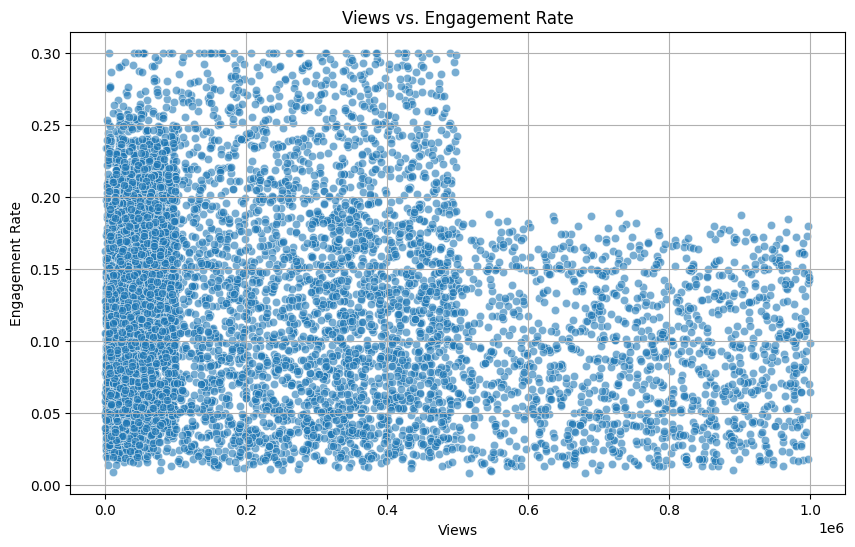

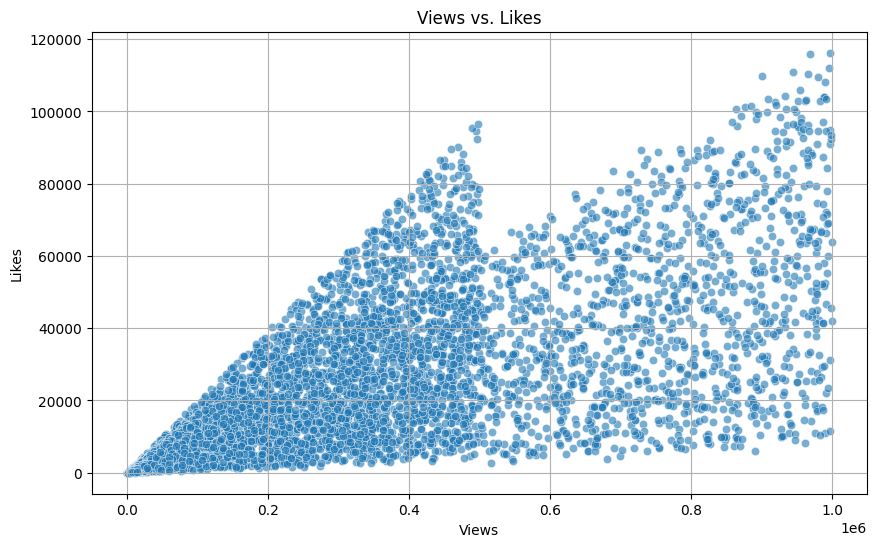

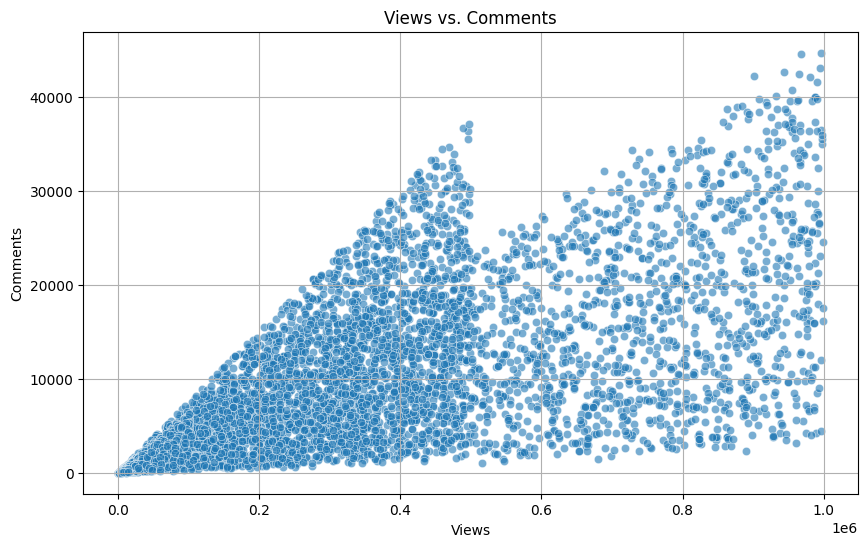

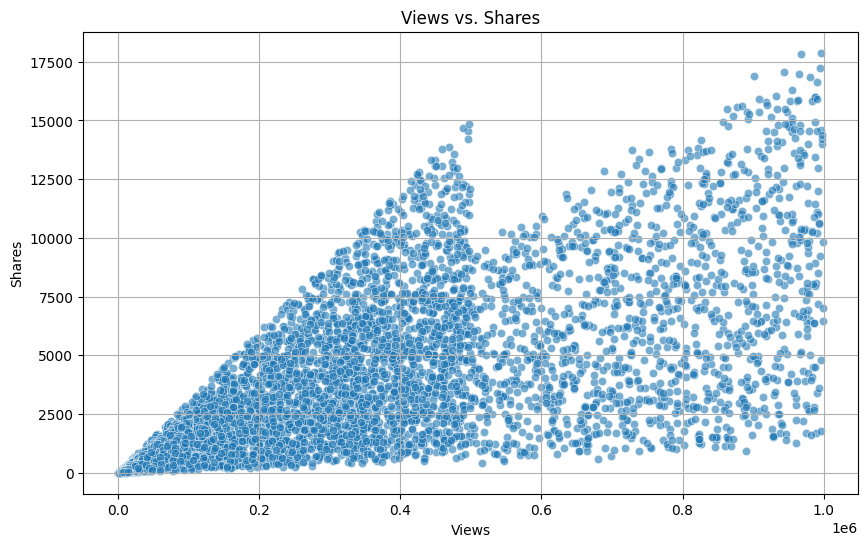

In [8]:
engagement_metrics = ['engagement_rate', 'likes', 'comments', 'shares']

for metric in engagement_metrics:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='views', y=metric, alpha=0.6)
    plt.title(f'Views vs. {metric.replace("_", " ").title()}')
    plt.xlabel('Views')
    plt.ylabel(metric.replace("_", " ").title())
    plt.grid(True)
    plt.show()

Identify Temporal Performance Patterns:

Extract the hour of day and day of week from the 'post_datetime' column, visualize the average 'engagement_rate' and the proportion of 'is_viral' posts across these temporal features to uncover optimal posting patterns.

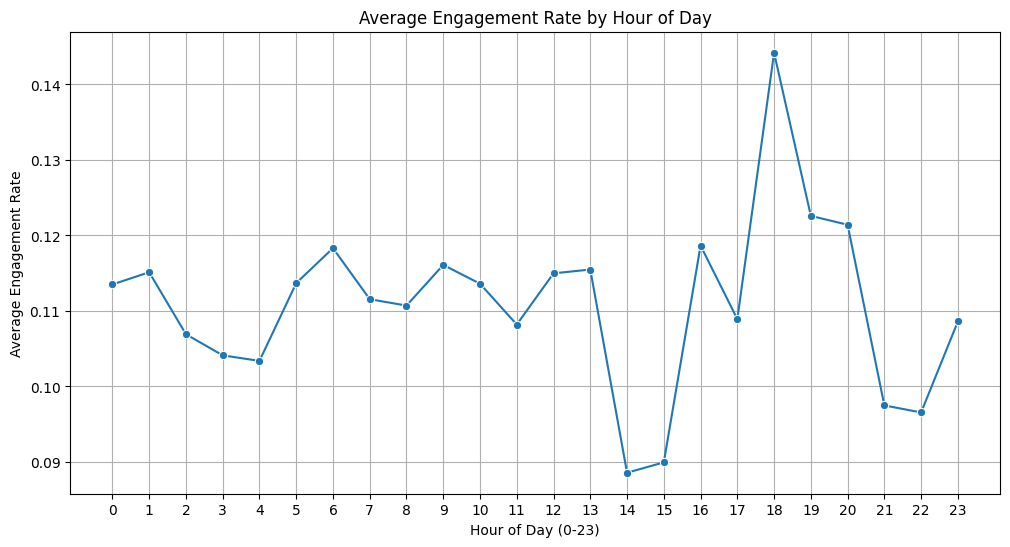

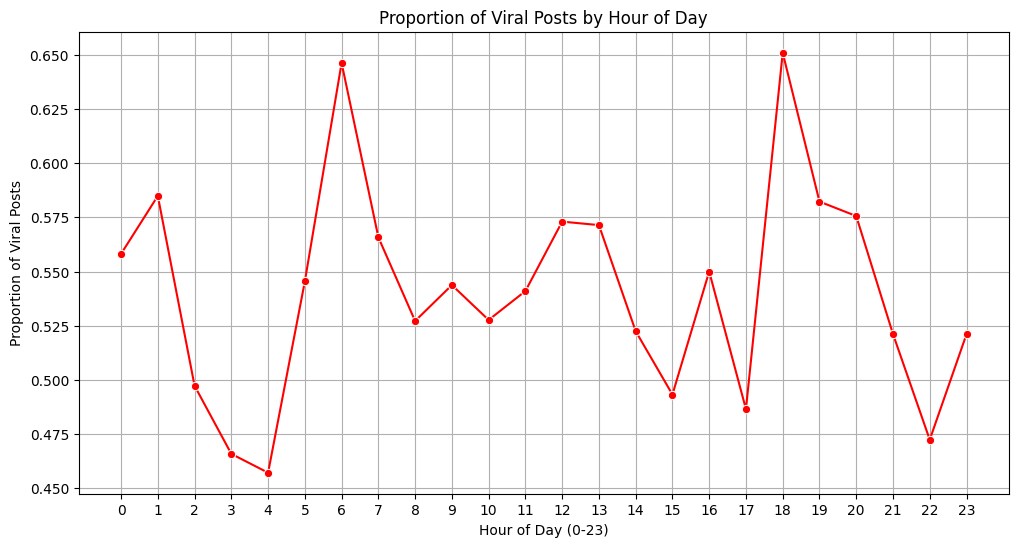

In [9]:
df['hour_of_day'] = df['post_datetime'].dt.hour

hourly_engagement = df.groupby('hour_of_day')['engagement_rate'].mean().reset_index()
hourly_viral_proportion = df.groupby('hour_of_day')['is_viral'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_engagement, x='hour_of_day', y='engagement_rate', marker='o')
plt.title('Average Engagement Rate by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Engagement Rate')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_viral_proportion, x='hour_of_day', y='is_viral', marker='o', color='red')
plt.title('Proportion of Viral Posts by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Proportion of Viral Posts')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Calculate the average engagement rate & proportion of viral posts per day, and then visualize these trends to identify daily patterns.



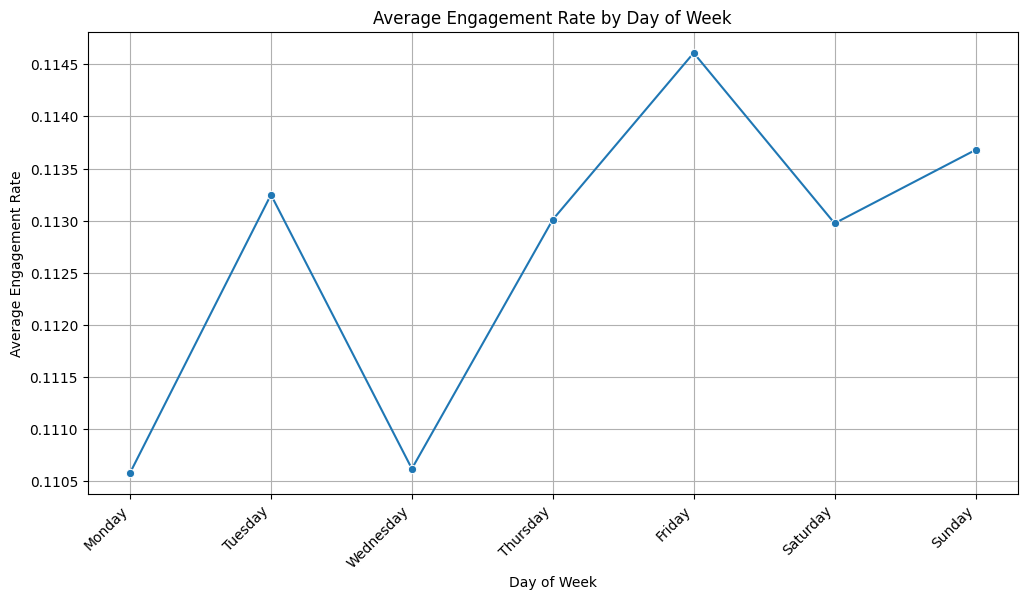

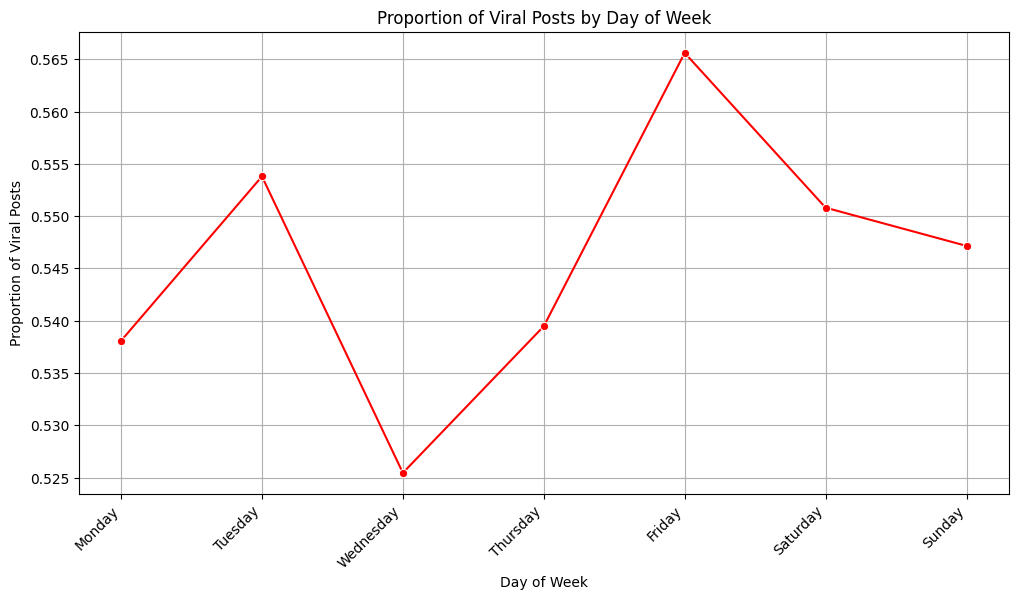

In [10]:
df['day_of_week'] = df['post_datetime'].dt.day_name()

day_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_of_week_order, ordered=True)

daily_engagement = df.groupby('day_of_week', observed=False)['engagement_rate'].mean().reset_index()
daily_viral_proportion = df.groupby('day_of_week', observed=False)['is_viral'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_engagement, x='day_of_week', y='engagement_rate', marker='o')
plt.title('Average Engagement Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_viral_proportion, x='day_of_week', y='is_viral', marker='o', color='red')
plt.title('Proportion of Viral Posts by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Proportion of Viral Posts')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

Compare Viral vs. Non-Viral Post Characteristics:

Analyze & visualize the distribution of key features ('platform', 'content_type', 'topic', 'sentiment_score', 'views', 'likes', 'comments', 'shares', 'engagement_rate') for posts marked as 'is_viral=1' versus 'is_viral=0'.


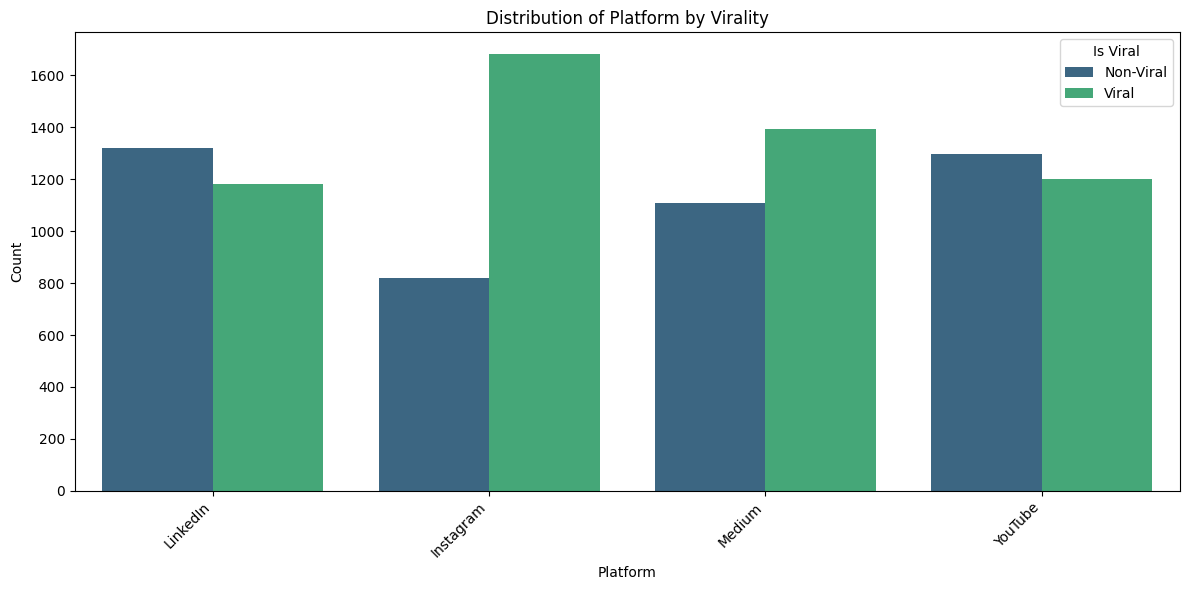

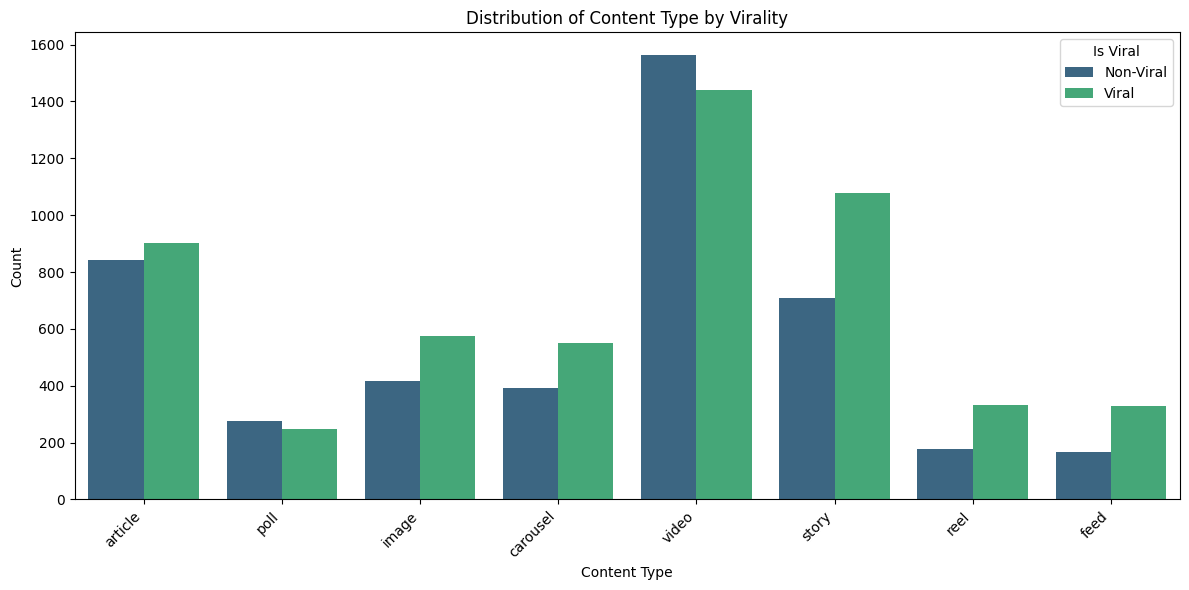

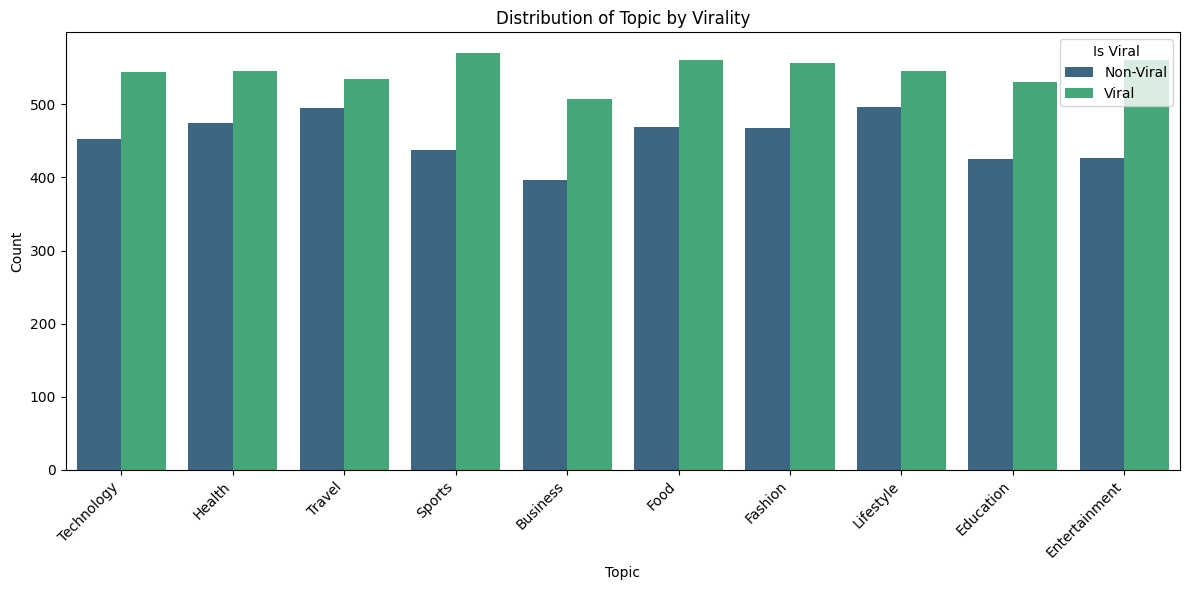

In [11]:
categorical_features = ['platform', 'content_type', 'topic']

for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=feature, hue='is_viral', palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Virality')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Is Viral', labels=['Non-Viral', 'Viral'])
    plt.tight_layout()
    plt.show()

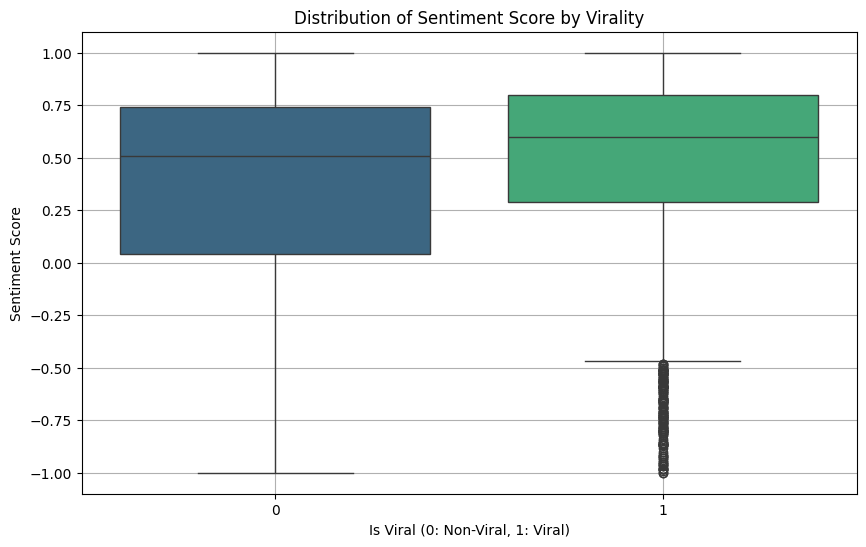

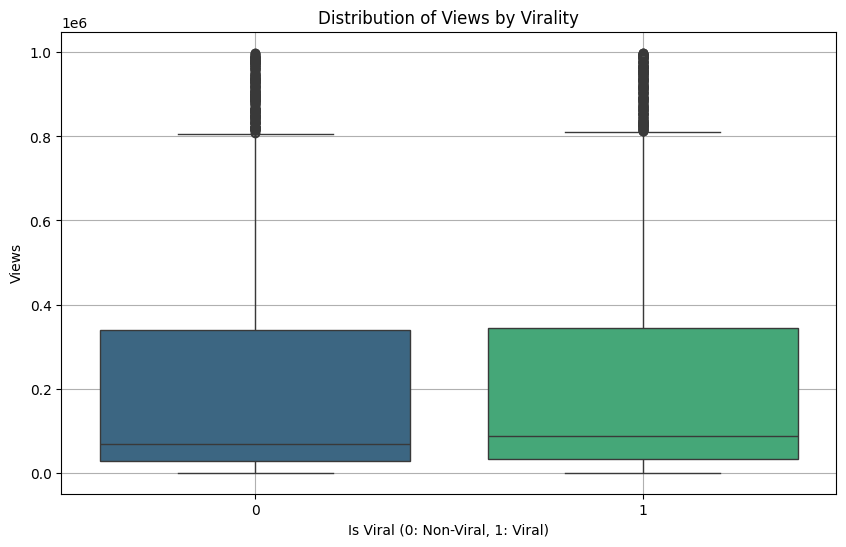

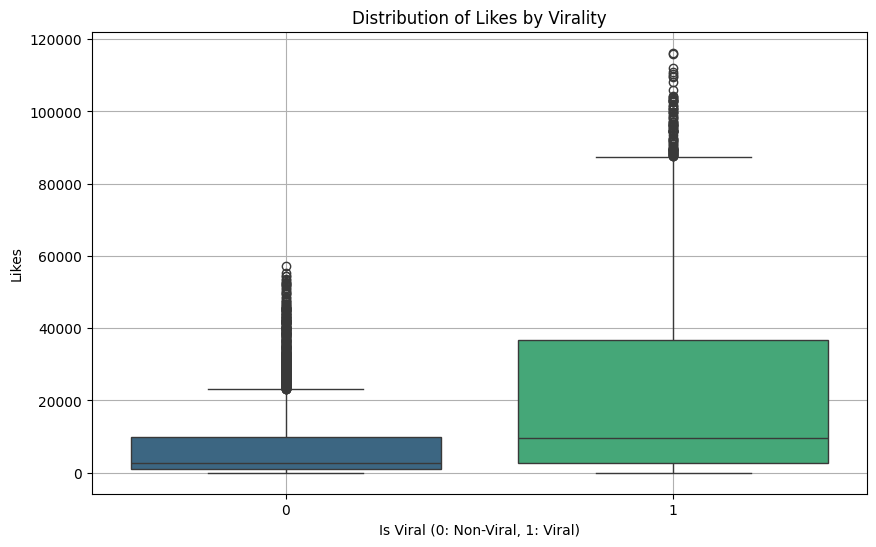

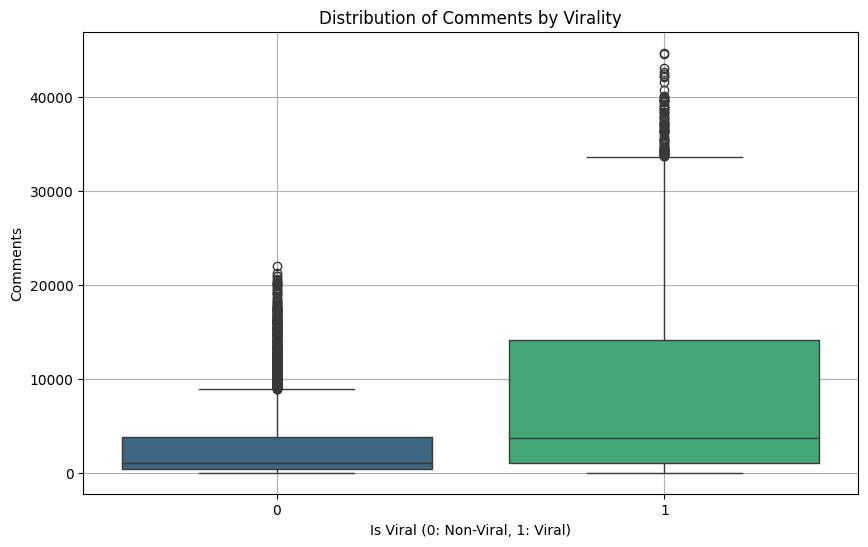

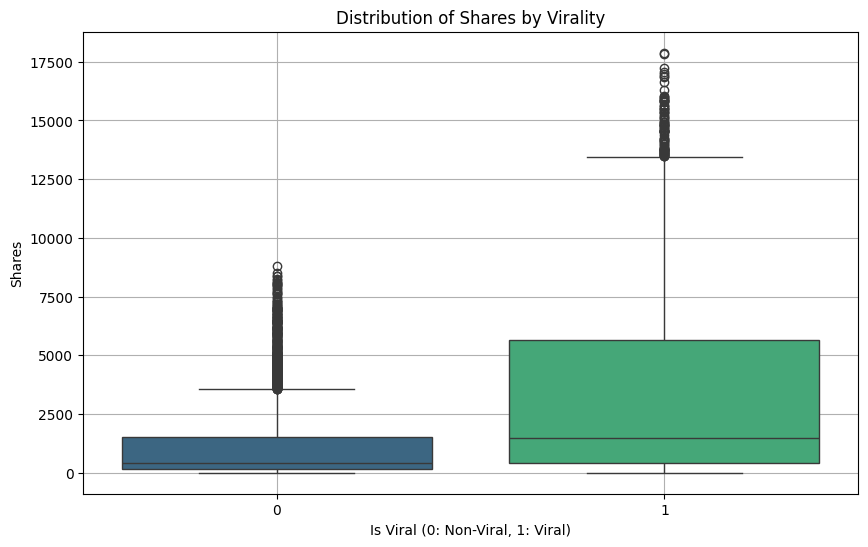

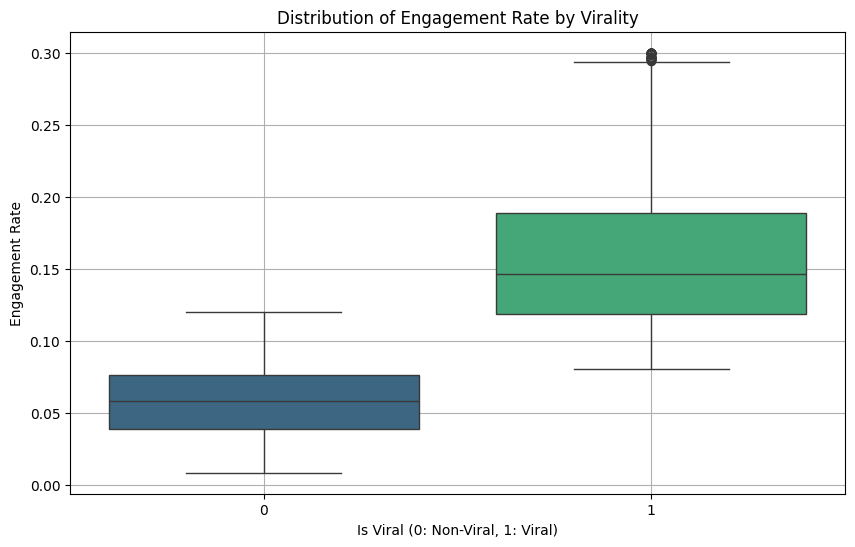

In [12]:
numerical_features = ['sentiment_score', 'views', 'likes', 'comments', 'shares', 'engagement_rate']

for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='is_viral', y=feature, hue='is_viral', palette='viridis', legend=False)
    plt.title(f'Distribution of {feature.replace('_', ' ').title()} by Virality')
    plt.xlabel('Is Viral (0: Non-Viral, 1: Viral)')
    plt.ylabel(feature.replace('_', ' ').title())
    plt.grid(True)
    plt.show()

### 3. Feature Engineering

Engineer Engagement Ratios:

Create new features representing engagement ratios by dividing 'likes', 'comments', and 'shares' by 'views'. Handle potential division by zero to avoid errors.

To create the new engagement ratio features, divide 'likes', 'comments', and 'shares' by 'views', handling potential division by zero by replacing the denominator with 1 to avoid errors and then setting the result to 0 where 'views' was originally 0.


In [13]:
df['likes_per_view'] = df['likes'] / df['views'].replace(0, 1)
df['comments_per_view'] = df['comments'] / df['views'].replace(0, 1)
df['shares_per_view'] = df['shares'] / df['views'].replace(0, 1)

df.loc[df['views'] == 0, ['likes_per_view', 'comments_per_view', 'shares_per_view']] = 0

print("New engagement ratio features created. \n")
print(df[['views', 'likes', 'comments', 'shares', 'likes_per_view', 'comments_per_view', 'shares_per_view']].head())

New engagement ratio features created. 

   views  likes  comments  shares  likes_per_view  comments_per_view  \
0  37781   1202       462     185        0.031815           0.012228   
1  23541   1399       538     215        0.059428           0.022854   
2  30714   1663       639     255        0.054145           0.020805   
3  31294   1372       528     211        0.043842           0.016872   
4  43129   2234       859     343        0.051798           0.019917   

   shares_per_view  
0         0.004897  
1         0.009133  
2         0.008302  
3         0.006743  
4         0.007953  


Engineer Posting Window:

Create a new feature `posting_window` from `hour_of_day` column, categorizing hours into 'Morning', 'Afternoon', 'Evening', and 'Night'.


In [14]:
bins = [-1, 5, 11, 17, 23]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

df['posting_window'] = pd.cut(df['hour_of_day'], bins=bins, labels=labels, right=True, ordered=False)

print("Posting window feature created.\n")
print(df['posting_window'].value_counts())
print(df[['hour_of_day', 'posting_window']].head())

Posting window feature created.

posting_window
Evening      3979
Morning      3212
Afternoon    1826
Night         983
Name: count, dtype: int64
   hour_of_day posting_window
0            9        Morning
1            9        Morning
2           14      Afternoon
3           22        Evening
4           10        Morning


Engineer Hashtags Count:

Add a `hashtags_count` feature to `df` by counting the number of hashtags in the 'hashtags' column.


In [15]:
df['hashtags_count'] = df['hashtags'].apply(lambda x: len(x.split()) if isinstance(x, str) and x.strip() != '' else 0)

print("Hashtags count feature created.")
print(df[['hashtags', 'hashtags_count']].head())

Hashtags count feature created.
                                            hashtags  hashtags_count
0  #AI #Innovation #TechTrends #Programming #Codi...               7
1  #Fitness #Nutrition #Wellness #Health #MentalH...               6
2  #Travel #Journey #Adventure #Tourism #ExploreM...               6
3                         #Cricket #Workout #Fitness               3
4             #Entrepreneur #Leadership #StartupLife               3


Normalize Performance Metrics by Platform:

Normalize 'views', 'likes', 'comments', 'shares', & 'engagement_rate' within each 'platform' by calculating z-scores for each metric.

This will help in comparing performance across different platforms on a standardized scale.


In [16]:
numerical_features_to_normalize = ['views', 'likes', 'comments', 'shares', 'engagement_rate']

for feature in numerical_features_to_normalize:
    df[f'{feature}_normalized'] = df.groupby('platform')[feature].transform(lambda x: (x - x.mean()) / x.std())

print("Normalized performance metrics created.\n")
print(df[[col for col in df.columns if '_normalized' in col]].head())

Normalized performance metrics created.

   views_normalized  likes_normalized  comments_normalized  shares_normalized  \
0          0.846564         -0.127331            -0.127631          -0.124314   
1         -0.160742          0.075790             0.076108           0.076750   
2          0.346660          0.347993             0.346867           0.344836   
3          0.387688          0.047951             0.049301           0.049942   
4          1.224869          0.936736             0.936638           0.934625   

   engagement_rate_normalized  
0                   -0.874005  
1                    0.367091  
2                    0.127633  
3                   -0.333763  
4                    0.022504  


### 4. Modeling & Prediction

Define Target Variables:

Define `is_viral` as the target variable for the classification task.


Prepare Features for Modeling:

Select the most relevant features, including the engineered ones, for training the models.

Handle categorical features through appropriate encoding (one-hot encoding), & ensure all features are in a numerical format suitable for ML algorithms.

Split the data into training and testing sets.


In [17]:
from sklearn.model_selection import train_test_split

# 1. Define the target variable y
y = df['is_viral']

# 2. Create a list of numerical features
numerical_features = ['sentiment_score', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'hour_of_day', 'likes_per_view', 'comments_per_view', 'shares_per_view', 'hashtags_count', 'views_normalized', 'likes_normalized', 'comments_normalized', 'shares_normalized', 'engagement_rate_normalized']

# 3. Create a list of categorical features
categorical_features = ['platform', 'content_type', 'topic', 'language', 'region', 'day_of_week', 'posting_window']

# 4. Combine the numerical and categorical features to create the feature set X
X = df[numerical_features + categorical_features]

# 5. Apply one-hot encoding to the categorical features in X
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 6. Split the feature set X and the target variable y into training and testing sets (80:20 Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features prepared and data split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("\nFirst 5 rows of the processed feature set X:")
print(X.head())

Features prepared and data split into training and testing sets.
Shape of X_train: (8000, 60)
Shape of X_test: (2000, 60)
Shape of y_train: (8000,)
Shape of y_test: (2000,)

First 5 rows of the processed feature set X:
   sentiment_score  views  likes  comments  shares  engagement_rate  \
0             0.76  37781   1202       462     185           0.0490   
1             0.46  23541   1399       538     215           0.0915   
2            -0.01  30714   1663       639     255           0.0833   
3             0.55  31294   1372       528     211           0.0675   
4             0.70  43129   2234       859     343           0.0797   

   hour_of_day  likes_per_view  comments_per_view  shares_per_view  ...  \
0            9        0.031815           0.012228         0.004897  ...   
1            9        0.059428           0.022854         0.009133  ...   
2           14        0.054145           0.020805         0.008302  ...   
3           22        0.043842           0.016872     

Build & Evaluate Baseline Models:

Train and evaluate a baseline machine learning model (Logistic Regression) using cross-validation. This will provide a fundamental benchmark for model performance.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Instantiate a LogisticRegression model
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')

# Print the mean accuracy and standard deviation
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation accuracy scores: [0.93625  0.9225   0.918125 0.92125  0.924375]
Mean cross-validation accuracy: 0.9245
Standard deviation of cross-validation accuracy: 0.0062


Build & Evaluate Advanced Models:

Train and evaluate advanced models like Random Forest or XGBoost. Implement cross-validation to assess their performance robustly and compare them against the baseline models to identify improvements.


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)

# Perform 5-fold cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

# Print the mean accuracy and standard deviation
print(f"Random Forest Cross-validation accuracy scores: {cv_scores_rf}")
print(f"Random Forest Mean cross-validation accuracy: {cv_scores_rf.mean():.4f}")
print(f"Random Forest Standard deviation of cross-validation accuracy: {cv_scores_rf.std():.4f}")

Random Forest Cross-validation accuracy scores: [1.       0.9975   0.999375 0.998125 0.999375]
Random Forest Mean cross-validation accuracy: 0.9989
Random Forest Standard deviation of cross-validation accuracy: 0.0009


Build & Evaluate Advanced Models (XGBoost Classifier):

Train and evaluate an XGBoost Classifier model. Implement cross-validation to assess its performance robustly and compare it against the previously trained models (Logistic Regression and Random Forest) to identify further improvements for the `is_viral` classification task.


In [20]:
from xgboost import XGBClassifier

# Instantiate an XGBClassifier model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Perform 5-fold cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')

# Print the mean accuracy and standard deviation
print(f"XGBoost Cross-validation accuracy scores: {cv_scores_xgb}")
print(f"XGBoost Mean cross-validation accuracy: {cv_scores_xgb.mean():.4f}")
print(f"XGBoost Standard deviation of cross-validation accuracy: {cv_scores_xgb.std():.4f}")

XGBoost Cross-validation accuracy scores: [1.       0.999375 0.99875  0.999375 0.999375]
XGBoost Mean cross-validation accuracy: 0.9994
XGBoost Standard deviation of cross-validation accuracy: 0.0004


#### 1. Summary of Cross-Validation Results:

**Logistic Regression Model:**
- Mean Cross-Validation Accuracy: 0.9245
- Standard Deviation of Cross-Validation Accuracy: 0.0062

**Random Forest Model:**
- Mean Cross-Validation Accuracy: 0.9989
- Standard Deviation of Cross-Validation Accuracy: 0.0009

**XGBoost Model:**
- Mean Cross-Validation Accuracy: 0.9994
- Standard Deviation of Cross-Validation Accuracy: 0.0004

#### 2. Model Performance Comparison:

Comparing the models, the **XGBoost Classifier** slightly outperformed the Random Forest model, and both significantly outperformed the Logistic Regression model.

The Random Forest achieved a mean cross-validation accuracy of approximately 0.9989, and XGBoost achieved 0.9994, which are both substantially higher than the Logistic Regression's mean accuracy of 0.9245.

#### 3. Role of Cross-Validation & Overfitting:

Cross-validation is a crucial technique for obtaining a more reliable estimate of a model's performance on unseen data and for detecting overfitting. By splitting the training data into multiple folds and training/evaluating the model on different combinations, it provides a robust measure of how well the model generalizes.

-   **Logistic Regression**: The c-v scores for Logistic Regression (`[0.93625, 0.9225, 0.918125, 0.92125, 0.924375]`) show a relatively small standard deviation (0.0062). This consistency indicates that the model is performing similarly across different subsets of the data, suggesting it is generalizing reasonably well and is not severely overfitting to any particular fold of the training data. The accuracy, while decent, indicates there's room for improvement.

-   **Random Forest**: The cross-validation scores for Random Forest (`[1., 0.9975, 0.999375, 0.998125, 0.999375]`) are remarkably high and extremely consistent, with a very low standard deviation (0.0009). This consistency, coupled with the high accuracy, suggests that the Random Forest model is generalizing exceptionally well and is not overfitting. If there was significant overfitting, we would expect to see a larger variance in accuracy across the folds, with some folds performing much worse than others.

-   **XGBoost**: The cross-validation scores for XGBoost (`[1., 0.999375, 0.99875, 0.999375, 0.999375]`) are also extremely high and consistent, with an even lower standard deviation (0.0004) than Random Forest. This indicates that XGBoost is also generalizing exceptionally well and performing very robustly across different data subsets, showing no signs of overfitting. The slightly higher mean accuracy and lower standard deviation suggest it might be marginally more stable or performant than Random Forest for this dataset.


### 5. Feature Importance (XGBoost Model)

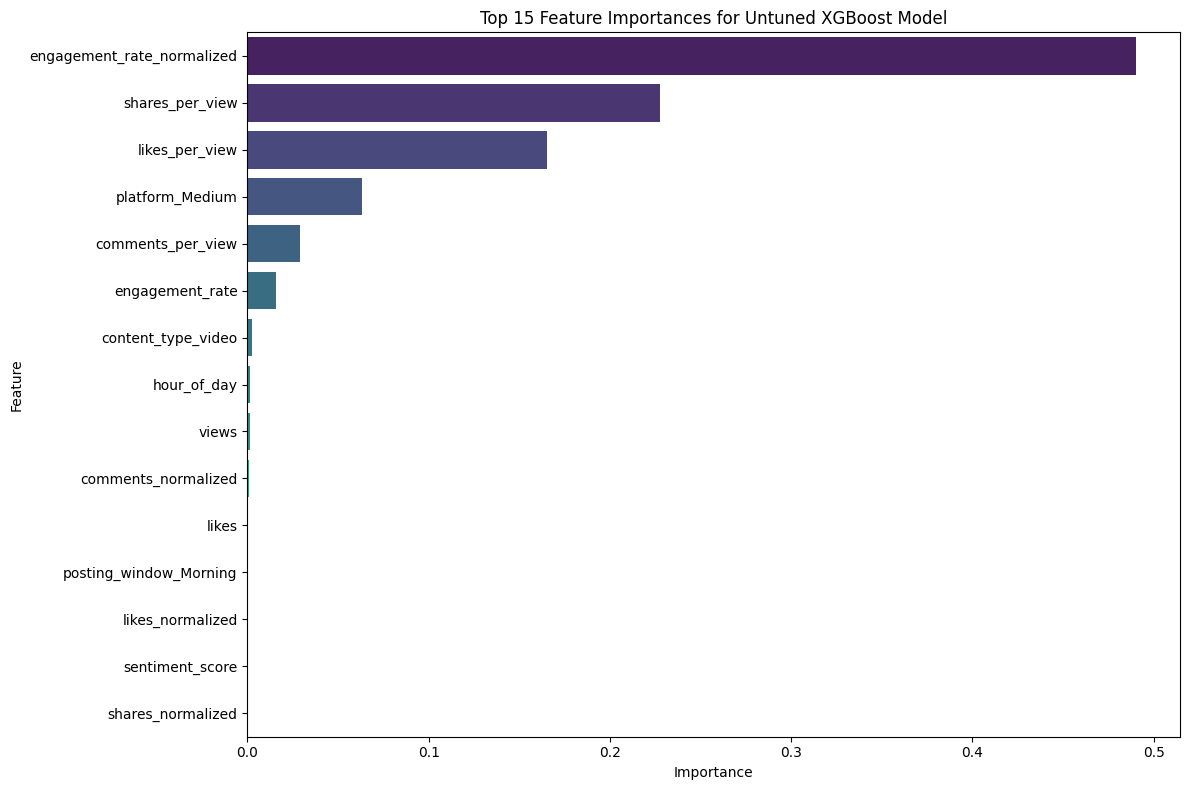

Selected features for xgboost model:
['engagement_rate_normalized', 'shares_per_view', 'likes_per_view', 'platform_Medium', 'comments_per_view', 'engagement_rate', 'content_type_video', 'hour_of_day', 'views', 'comments_normalized', 'likes', 'posting_window_Morning', 'likes_normalized', 'sentiment_score', 'shares_normalized']


In [21]:
# Ensure the untuned XGBoost model is fitted to the training data
xgb_model.fit(X_train, y_train)

# Access feature importances
feature_importances_untuned = xgb_model.feature_importances_

# Create a DataFrame for feature importances
feature_importance_df_untuned = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_untuned
})

# Sort by importance and select the top 15 features
top_15_features_untuned = feature_importance_df_untuned.sort_values(by='Importance', ascending=False).head(15)

# Store the selected features names in a list
selected_features_untuned = top_15_features_untuned['Feature'].tolist()

# Visualize the top 15 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features_untuned, palette='viridis')
plt.title('Top 15 Feature Importances for Untuned XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Selected features for xgboost model:")
print(selected_features_untuned)

### 6. Hyperparameter Tune XGBoost Model

Define Hyperparameter Bounds for Bayesian Optimization (Top 15 Features)

In [22]:
param_bounds = {
    'n_estimators': (100, 1000),
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'gamma': (0, 0.5),
    'reg_alpha': (0, 1.0),
    'reg_lambda': (0, 1.0)
}

param_bounds

{'n_estimators': (100, 1000),
 'max_depth': (3, 10),
 'learning_rate': (0.01, 0.3),
 'subsample': (0.6, 1.0),
 'colsample_bytree': (0.6, 1.0),
 'gamma': (0, 0.5),
 'reg_alpha': (0, 1.0),
 'reg_lambda': (0, 1.0)}

Perform Bayesian Optimization (Top 15 Features)

In [23]:
pip install bayesian-optimization

In [24]:
from bayes_opt import BayesianOptimization
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# 2. Create X_train_selected using the previously identified top features
X_train_selected = X_train[selected_features_untuned]

# 3. Define the objective function for Bayesian Optimization
def xgb_evaluate(**params):
    # Ensure integer parameters are cast to int
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])

    # Instantiate XGBoost Classifier with given hyperparameters
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        **params
    )

    # Perform 5-fold cross-validation and return the mean accuracy
    scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# 4. Instantiate BayesianOptimization
optimizer = BayesianOptimization(
    f=xgb_evaluate,
    pbounds=param_bounds,
    random_state=42,
    verbose=2
)

# 5. Run the Bayesian Optimization process
optimizer.maximize(
    init_points=5,
    n_iter=10
)

# 6. Print the best found parameters and corresponding best score
print(f"Best score: {optimizer.max['target']:.4f}")
print("Best parameters:")
for param, value in optimizer.max['params'].items():
    if param in ['n_estimators', 'max_depth']:
        print(f"  {param}: {int(value)}")
    else:
        print(f"  {param}: {value:.4f}")

# Store the best parameters
best_params = optimizer.max['params']

# Train the final XGBoost model with the best parameters
tuned_xgb_model_final = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda']
)
tuned_xgb_model_final.fit(X_train_selected, y_train)

print("\nFinal XGBoost model trained with best hyperparameters on top 15 selected features.")

|   iter    |  target   | n_esti... | max_depth | learni... | subsample | colsam... |   gamma   | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------
| 1         | 0.998875  | 437.08610 | 9.6550001 | 0.2222782 | 0.8394633 | 0.6624074 | 0.0779972 | 0.0580836 | 0.8661761 |
| 2         | 0.999375  | 641.00351 | 7.9565080 | 0.0159695 | 0.9879639 | 0.9329770 | 0.1061695 | 0.1818249 | 0.1834045 |
| 3         | 0.99925   | 373.81801 | 6.6732950 | 0.1352640 | 0.7164916 | 0.8447411 | 0.0697469 | 0.2921446 | 0.3663618 |
| 4         | 0.999375  | 510.46298 | 8.4962317 | 0.0679053 | 0.8056937 | 0.8369658 | 0.0232252 | 0.6075448 | 0.1705241 |
| 5         | 0.99925   | 158.54643 | 9.6421987 | 0.2900332 | 0.9233589 | 0.7218455 | 0.0488360 | 0.6842330 | 0.4401524 |
| 6         | 0.99925   | 509.08695 | 8.3863977 | 0.2587998 | 0.9400556 | 0.7892793 | 0.4358876 | 0.4477656 | 0.0103783 |
| 7         | 0.999     

In [25]:
# 1. Perform 5-fold cross-validation on the tuned XGBoost model
cv_scores_tuned_xgb = cross_val_score(tuned_xgb_model_final, X_train_selected, y_train, cv=5, scoring='accuracy')

# 2. Calculate and print the mean accuracy and standard deviation
print(f"Tuned XGBoost Cross-validation accuracy scores: {cv_scores_tuned_xgb}")
print(f"Tuned XGBoost Mean cross-validation accuracy: {cv_scores_tuned_xgb.mean():.4f}")
print(f"Tuned XGBoost Standard deviation of cross-validation accuracy: {cv_scores_tuned_xgb.std():.4f}")

Tuned XGBoost Cross-validation accuracy scores: [1.       0.999375 0.99875  0.999375 0.999375]
Tuned XGBoost Mean cross-validation accuracy: 0.9994
Tuned XGBoost Standard deviation of cross-validation accuracy: 0.0004


Compare Tuned vs. Untuned XGBoost Performance (Top 15 Features)


In [26]:
print("Untuned XGBoost Model Performance (All features):")
print(f"  Mean cross-validation accuracy: {cv_scores_xgb.mean():.4f}")
print(f"  Standard deviation of cross-validation accuracy: {cv_scores_xgb.std():.4f}")

print("\nTuned XGBoost Model Performance (Top 15 features):")
print(f"  Mean cross-validation accuracy: {cv_scores_tuned_xgb.mean():.4f}")
print(f"  Standard deviation of cross-validation accuracy: {cv_scores_tuned_xgb.std():.4f}")

Untuned XGBoost Model Performance (All features):
  Mean cross-validation accuracy: 0.9994
  Standard deviation of cross-validation accuracy: 0.0004

Tuned XGBoost Model Performance (Top 15 features):
  Mean cross-validation accuracy: 0.9994
  Standard deviation of cross-validation accuracy: 0.0004


### 7. Model Explainability

In [30]:
!pip install shap

Prepare Data for SHAP.

In [31]:
X_test_selected = X_test[selected_features_untuned]
print(f"Shape of X_test_selected: {X_test_selected.shape}")
print("\nFirst 5 rows of X_test_selected:")
print(X_test_selected.head())

Shape of X_test_selected: (2000, 15)

First 5 rows of X_test_selected:
      engagement_rate_normalized  shares_per_view  likes_per_view  \
6252                   -0.355333         0.011099        0.072248   
4684                    1.877253         0.029998        0.194995   
1731                    0.501422         0.009545        0.062379   
4742                   -0.402078         0.011825        0.076875   
4521                   -0.679311         0.009616        0.062507   

      platform_Medium  comments_per_view  engagement_rate  content_type_video  \
6252             True           0.027773           0.1112               False   
4684            False           0.074995           0.3000               False   
1731            False           0.024007           0.0961               False   
4742            False           0.029567           0.1183               False   
4521            False           0.024038           0.0962               False   

      hour_of_day   views  

In [32]:
import shap

# Initialize Javascript for SHAP plots
shap.initjs()

# Create a SHAP TreeExplainer object
explainer = shap.TreeExplainer(tuned_xgb_model_final)

# Calculate SHAP values for the test set (selected features)
shap_values = explainer.shap_values(X_test_selected)

SHAP explainer initialized and SHAP values calculated.


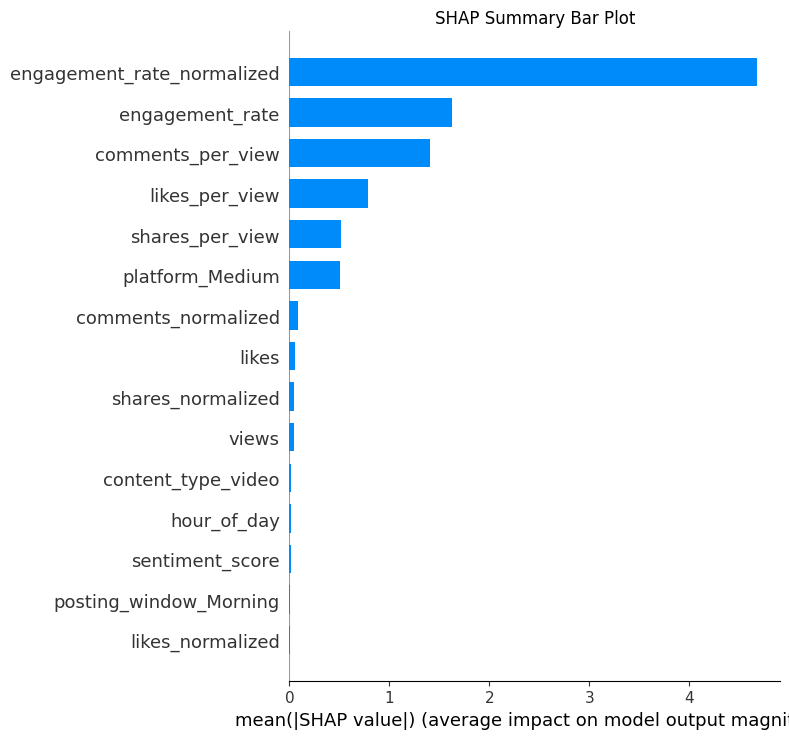

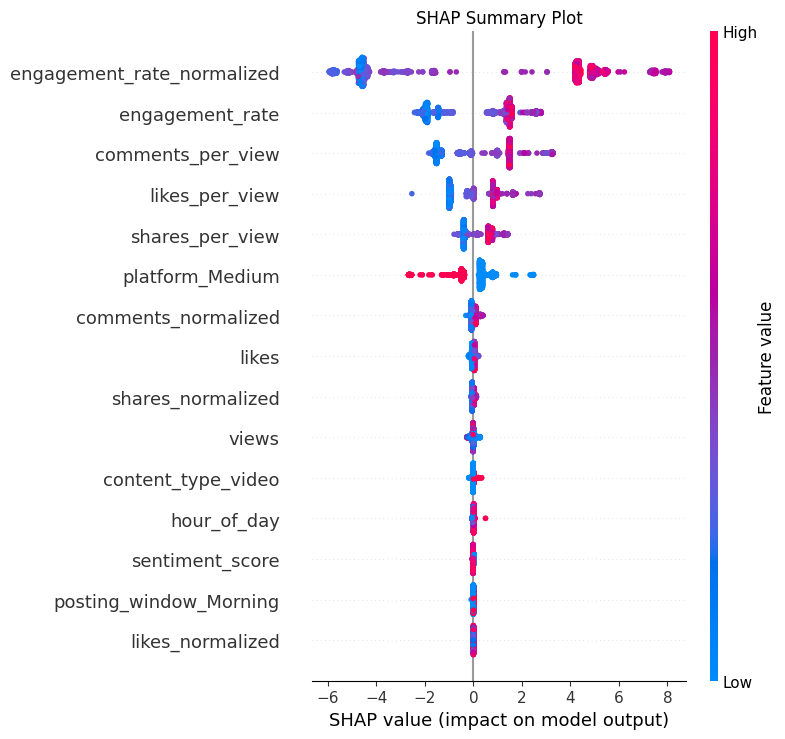

SHAP summary plots generated.


In [33]:
shap.summary_plot(shap_values, X_test_selected, plot_type="bar", show=False)
plt.title('SHAP Summary Bar Plot')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_selected, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

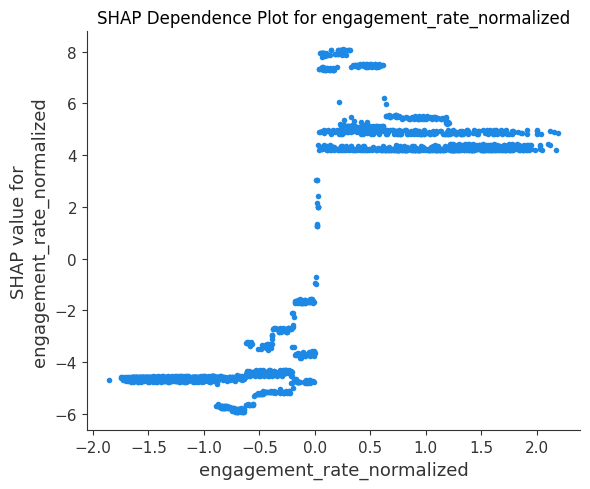

<Figure size 1000x600 with 0 Axes>

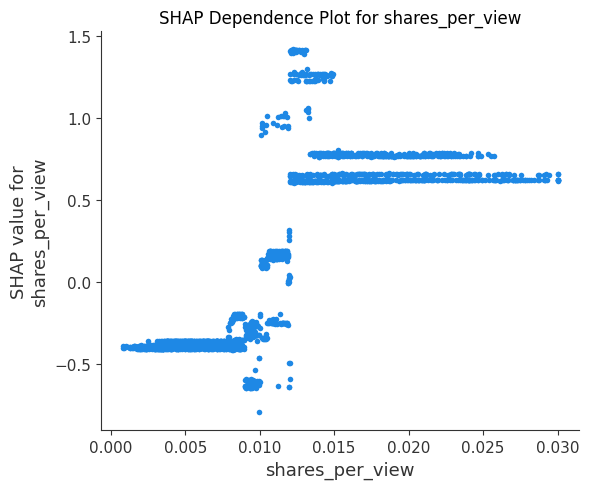

<Figure size 1000x600 with 0 Axes>

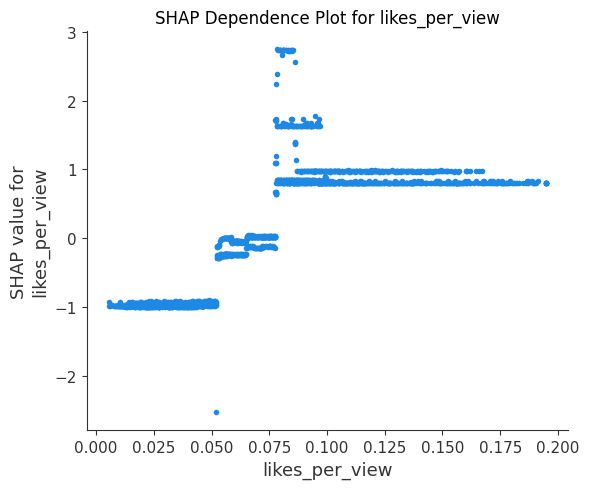

<Figure size 1000x600 with 0 Axes>

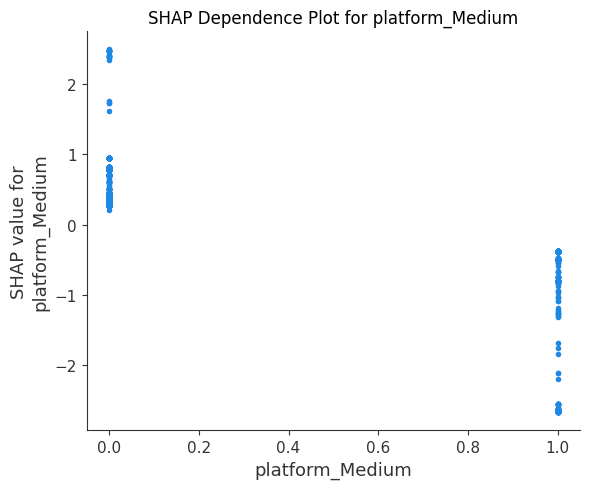

<Figure size 1000x600 with 0 Axes>

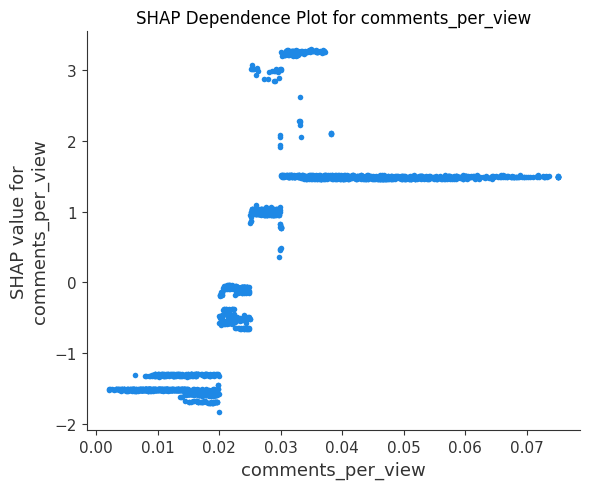

SHAP dependence plots for the top 5 features generated.


In [34]:
for feature in selected_features_untuned[:5]:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature, shap_values, X_test_selected, interaction_index=None, show=False)
    plt.title(f'SHAP Dependence Plot for {feature}')
    plt.tight_layout()
    plt.show()

### 8. Model Deployment

In [27]:
import joblib

# Save the tuned XGBoost model to a file
joblib.dump(tuned_xgb_model_final, 'xgboost_model.joblib')

print("Tuned XGBoost model saved successfully as 'xgboost_model.joblib'.")

Tuned XGBoost model saved successfully as 'xgboost_model.joblib'.


In [28]:
# Get the full list of one-hot encoded columns from the training set
full_ohe_columns = X_train.columns.tolist()

# Calculate platform normalization statistics
platform_normalization_stats = df.groupby('platform')[numerical_features_to_normalize].agg(['mean', 'std']).to_dict(orient='index')

# Prepare the metadata dictionary, using selected_features_untuned
feature_metadata = {
    'selected_features': selected_features_untuned,
    'full_ohe_columns': full_ohe_columns,
    'categorical_features': categorical_features,
    'numerical_features_to_normalize': numerical_features_to_normalize,
    'platform_normalization_stats': platform_normalization_stats
}

# Save the feature metadata to a file
joblib.dump(feature_metadata, 'feature_metadata.joblib')

print("Feature metadata saved successfully as 'feature_metadata.joblib'.")

Feature metadata saved successfully as 'feature_metadata.joblib'.


### 9. Save Processed Data for Tableau


In [29]:
df.to_csv('social_media_performance_dashboard.csv', index=False)
print("DataFrame 'df' saved to 'social_media_performance_dashboard.csv' successfully.")

DataFrame 'df' saved to 'social_media_performance_dashboard.csv' successfully.
